# Car Classification on Apple M3 Pro with PyTorch (MPS Acceleration)

This notebook demonstrates how to adapt a car image classification model to run efficiently on an Apple M3 Pro (36GB RAM) using PyTorch. We will leverage the Apple Metal Performance Shaders (MPS) backend for GPU acceleration and implement modern best practices for data loading, model fine-tuning, and optimization. The training and testing image datasets are assumed to be stored locally in directories (e.g., `train/` and `test/` folders with subfolders per class).

## 1. Environment Setup and Device Configuration

First, we ensure we are using the latest PyTorch (compatible with PyTorch 1.13+ or 2.x, referred to as "3.13" in the context of this task) and check for MPS availability. On Apple Silicon, the `"mps"` device allows PyTorch to utilize the Apple GPU for acceleration. We will use this device if available, otherwise fallback to CPU.



In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
import time


In [23]:
# =======================
# 1. Device Configuration
# =======================
device = torch.device("mps" if torch.backends.mps.is_available() else 
                      "cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: mps


In [24]:
# =======================
# 2. Dataset Preparation
# =======================
# Define dataset paths
train_dir = "/Users/idan/code/college-of-management-cars196/Data/train"
test_dir = "/Users/idan/code/college-of-management-cars196/Data/test"

# Define data transformations
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),       
    transforms.RandomHorizontalFlip(),       
    transforms.ToTensor(),                   
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  
])

test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load dataset
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

# Define DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

num_classes = len(train_dataset.classes)
print(f"Loaded {len(train_dataset)} training images in {num_classes} classes.")


Loaded 8144 training images in 196 classes.


In [34]:
# =======================
# 3. Model Selection
# =======================
import torchvision.models as models

def get_model(model_name):
    if model_name == "mobilenet":
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
    
    elif model_name == "resnet":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    # elif model_name == "googlenet":
    #     model = models.googlenet(weights=models.GoogLeNet_Weights.IMAGENET1K_V1, aux_logits=False)  # 🔹 כיבוי Auxiliary Classifiers
    #     in_features = model.fc.in_features
    #     model.fc = nn.Linear(in_features, num_classes)

    else:
        raise ValueError("Unknown model name")
    
    return model.to(device)


In [35]:
# =======================
# 4. Training Function
# =======================
def train_model(model, train_loader, test_loader, model_name, freeze=True, epochs=10):
    if freeze:
        for param in model.parameters():
            param.requires_grad = False
        if model_name == "resnet" or model_name == "googlenet":
            for param in model.fc.parameters():
                param.requires_grad = True
        elif model_name == "mobilenet":
            for param in model.classifier[1].parameters():
                param.requires_grad = True
    else:
        for param in model.parameters():
            param.requires_grad = True

    trainable_params = [param for param in model.parameters() if param.requires_grad]

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(trainable_params, lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

    train_acc_history = []
    val_acc_history = []

    best_val_acc = 0.0
    patience = 5
    epochs_no_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss, correct = 0.0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()

        train_loss /= len(train_dataset)
        train_acc = correct / len(train_dataset) * 100
        train_acc_history.append(train_acc)

        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
        val_loss /= len(test_dataset)
        val_acc = val_correct / len(test_dataset) * 100
        val_acc_history.append(val_acc)

        print(f"Epoch {epoch}: Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"best_{model_name}.pth")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print("Early stopping triggered.")
            break

    return train_acc_history, val_acc_history


In [36]:
# =======================
# 5. Train & Compare Models
# =======================
models_to_run = ["mobilenet", "resnet"]
results = {}

for model_name in models_to_run:
    print(f"\nTraining {model_name} with frozen layers...")
    model = get_model(model_name)
    train_acc_frozen, val_acc_frozen = train_model(model, train_loader, test_loader, model_name, freeze=True, epochs=10)

    print(f"\nFine-tuning {model_name}...")
    model.load_state_dict(torch.load(f"best_{model_name}.pth"))
    train_acc_full, val_acc_full = train_model(model, train_loader, test_loader, model_name, freeze=False, epochs=20)

    results[model_name] = {
        "train_acc_frozen": train_acc_frozen,
        "val_acc_frozen": val_acc_frozen,
        "train_acc_full": train_acc_full,
        "val_acc_full": val_acc_full
    }

print("\nTraining Complete!")


Training mobilenet with frozen layers...
Epoch 1: Train Acc=6.29%, Val Acc=16.57%
Epoch 2: Train Acc=18.69%, Val Acc=25.83%
Epoch 3: Train Acc=26.82%, Val Acc=31.72%
Epoch 4: Train Acc=31.56%, Val Acc=34.05%
Epoch 5: Train Acc=34.37%, Val Acc=36.30%
Epoch 6: Train Acc=36.90%, Val Acc=38.22%
Epoch 7: Train Acc=39.37%, Val Acc=38.71%
Epoch 8: Train Acc=40.69%, Val Acc=40.90%
Epoch 9: Train Acc=42.37%, Val Acc=41.03%
Epoch 10: Train Acc=43.17%, Val Acc=40.65%

Fine-tuning mobilenet...
Epoch 1: Train Acc=23.44%, Val Acc=40.03%
Epoch 2: Train Acc=40.26%, Val Acc=52.20%
Epoch 3: Train Acc=48.04%, Val Acc=60.39%
Epoch 4: Train Acc=53.97%, Val Acc=61.58%
Epoch 5: Train Acc=57.63%, Val Acc=66.91%
Epoch 6: Train Acc=59.06%, Val Acc=66.63%
Epoch 7: Train Acc=61.86%, Val Acc=71.15%
Epoch 8: Train Acc=62.95%, Val Acc=70.81%
Epoch 9: Train Acc=65.20%, Val Acc=71.30%
Epoch 10: Train Acc=67.26%, Val Acc=73.36%
Epoch 11: Train Acc=67.96%, Val Acc=77.40%
Epoch 12: Train Acc=68.61%, Val Acc=75.65%
Epoch

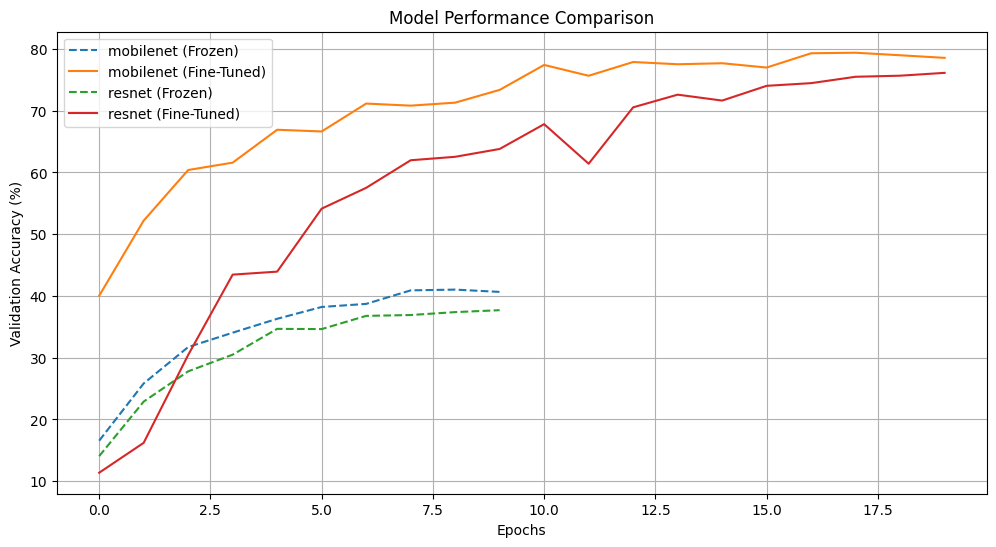

In [37]:
# =======================
# 6. Plot Results
# =======================
plt.figure(figsize=(12, 6))

for model_name in models_to_run:
    plt.plot(results[model_name]["val_acc_frozen"], linestyle='--', label=f"{model_name} (Frozen)")
    plt.plot(results[model_name]["val_acc_full"], label=f"{model_name} (Fine-Tuned)")

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy (%)")
plt.title("Model Performance Comparison")
plt.legend()
plt.grid()
plt.show()